# OrthoLoRA Adapter Analysis

Comprehensive analysis comparing LoRA, VeRA, and OrthoLoRA adapters across BigBench, MMLU, and Task-Specific evaluations.

**Data Source:** `src/analysis/adapters_results/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Style Setup
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ADAPTER_COLORS = {
    'lora': '#E63946',
    'vera': '#457B9D',
    'uiortholora': '#2A9D8F',
}
ADAPTER_LABELS = {
    'lora': 'LoRA',
    'vera': 'VeRA',
    'uiortholora': 'OrthoLoRA',
}
SIZE_MARKERS = {
    'small': 'o',
    'large': 's',
}

print("Libraries loaded and style set.")

Libraries loaded and style set.


In [2]:
# Configuration
BASE_PATH = 'adapters_results'

# Select Dataset and Threshold here
DATASET = 'hotpotqa'       # Options: 'hotpotqa', 'triviaqa'
THRESHOLD = '0.8'          # Options: '0.6', '0.8'

TARGET_DIR = os.path.join(BASE_PATH, DATASET, f'threshold_{THRESHOLD}')
BENCHMARK_DIR = os.path.join(BASE_PATH, DATASET)
print(f"Analyzing data from: {TARGET_DIR}")

# Helper functions for parsing names
def get_adapter_type(name):
    name = str(name).lower()
    if 'uiortholora' in name: return 'uiortholora'
    if 'vera' in name: return 'vera'
    if 'lora' in name: return 'lora'
    return 'unknown'

def extract_lr(name):
    m = re.search(r'lr([\de\-\.]+)', str(name))
    if m:
        return m.group(1)
    return None

def classify_size(row):
    adapter = row['adapter']
    name = str(row.get('model_name', ''))
    rank = row.get('rank', 0)
    
    if adapter == 'vera':
        return 'small'
    elif adapter == 'lora':
        try:
            return 'large' if float(rank) >= 3 else 'small'
        except:
            return 'small'
    elif adapter == 'uiortholora':
        # Parse s and v dimensions if available in name like _s1024_v32
        s_match = re.search(r'_s(\d+)', name)
        v_match = re.search(r'_v(\d+)', name)
        if s_match and v_match:
            s = int(s_match.group(1))
            v = int(v_match.group(1))
            return 'small' if s * v <= 1024 * 32 else 'large'
        if '_v0_' in name or name.endswith('_v0'):
            return 'small'
    return 'small'

Analyzing data from: adapters_results/hotpotqa/threshold_0.8


In [3]:
# Load CSVs
try:
    # Task specific data (accuracy, negative shift)
    gemma_path = os.path.join(TARGET_DIR, 'gemma-12b.csv')
    llama_path = os.path.join(TARGET_DIR, 'llama-3b.csv')
    
    df_gemma = pd.read_csv(gemma_path)
    df_llama = pd.read_csv(llama_path) # Uncomment if comparing architectures
    
    # Generalization data
    bb_path = os.path.join(BENCHMARK_DIR, 'bigbench_summary.csv')
    mmlu_path = os.path.join(BENCHMARK_DIR, 'mmlu_summary.csv')
    
    df_bb = pd.read_csv(bb_path)
    df_mmlu = pd.read_csv(mmlu_path)
    
    print("Files loaded successfully.")
    print(f"Gemma Task Rows: {len(df_gemma)}")
    print(f"BigBench Rows: {len(df_bb)}")
    print(f"MMLU Rows: {len(df_mmlu)}")

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Please ensure the directory structure exists and contains the CSV files.")

Files loaded successfully.
Gemma Task Rows: 200
BigBench Rows: 321
MMLU Rows: 314


In [4]:
# Normalize columns for merging
# Assumption: All CSVs have a 'model_name' or 'adapter_name' column that acts as a unique key

def normalize_df(df, prefix=''):
    # Ensure we have a join key
    if 'model_name' not in df.columns and 'model_path' in df.columns:
        df['model_name'] = df['model_path'].apply(lambda x: x.split('/')[-1])
    elif 'raw_adapter_name' in df.columns:
        df['model_name'] = df['raw_adapter_name']
    
    # Clean join key
    df['join_key'] = df['model_name'].astype(str).str.strip()
    return df

df_gemma = normalize_df(df_gemma)
df_bb = normalize_df(df_bb)
df_mmlu = normalize_df(df_mmlu)

# Rename metric columns to avoid collisions before merge
df_bb_clean = df_bb[['join_key', 'mean_accuracy']].rename(columns={'mean_accuracy': 'bigbench_acc'})
df_mmlu_clean = df_mmlu[['join_key', 'mmlu_acc']].rename(columns={'mmlu_acc': 'mmlu_accuracy'})

# Merge
df_merged = df_gemma.merge(df_bb_clean, on='join_key', how='left')
df_merged = df_merged.merge(df_mmlu_clean, on='join_key', how='left')

# Feature Engineering
df_merged['adapter'] = df_merged['model_name'].apply(get_adapter_type)
df_merged['lr'] = df_merged['model_name'].apply(extract_lr)
df_merged['size'] = df_merged.apply(classify_size, axis=1)

# Ensure numerics
numeric_cols = ['accuracy', 'negative_shift_score', 'bigbench_acc', 'mmlu_accuracy']
for col in numeric_cols:
    if col in df_merged.columns:
        df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

print(f"Merged Dataset Size: {len(df_merged)}")
df_merged[['adapter', 'lr', 'accuracy', 'negative_shift_score', 'bigbench_acc', 'mmlu_accuracy']].head()

Merged Dataset Size: 240


,adapter,lr,accuracy,negative_shift_score,bigbench_acc,mmlu_accuracy
0,lora,1e-2,0.007168,4048.4,0.375673,NaN
1,lora,1e-2,0.007168,4048.4,0.319956,NaN
2,lora,1e-2,0.000183,4208.3,0.370593,NaN
3,lora,1e-2,0.000183,4208.3,0.372682,NaN
4,lora,1e-2,0.017773,3922.3,0.294710,NaN


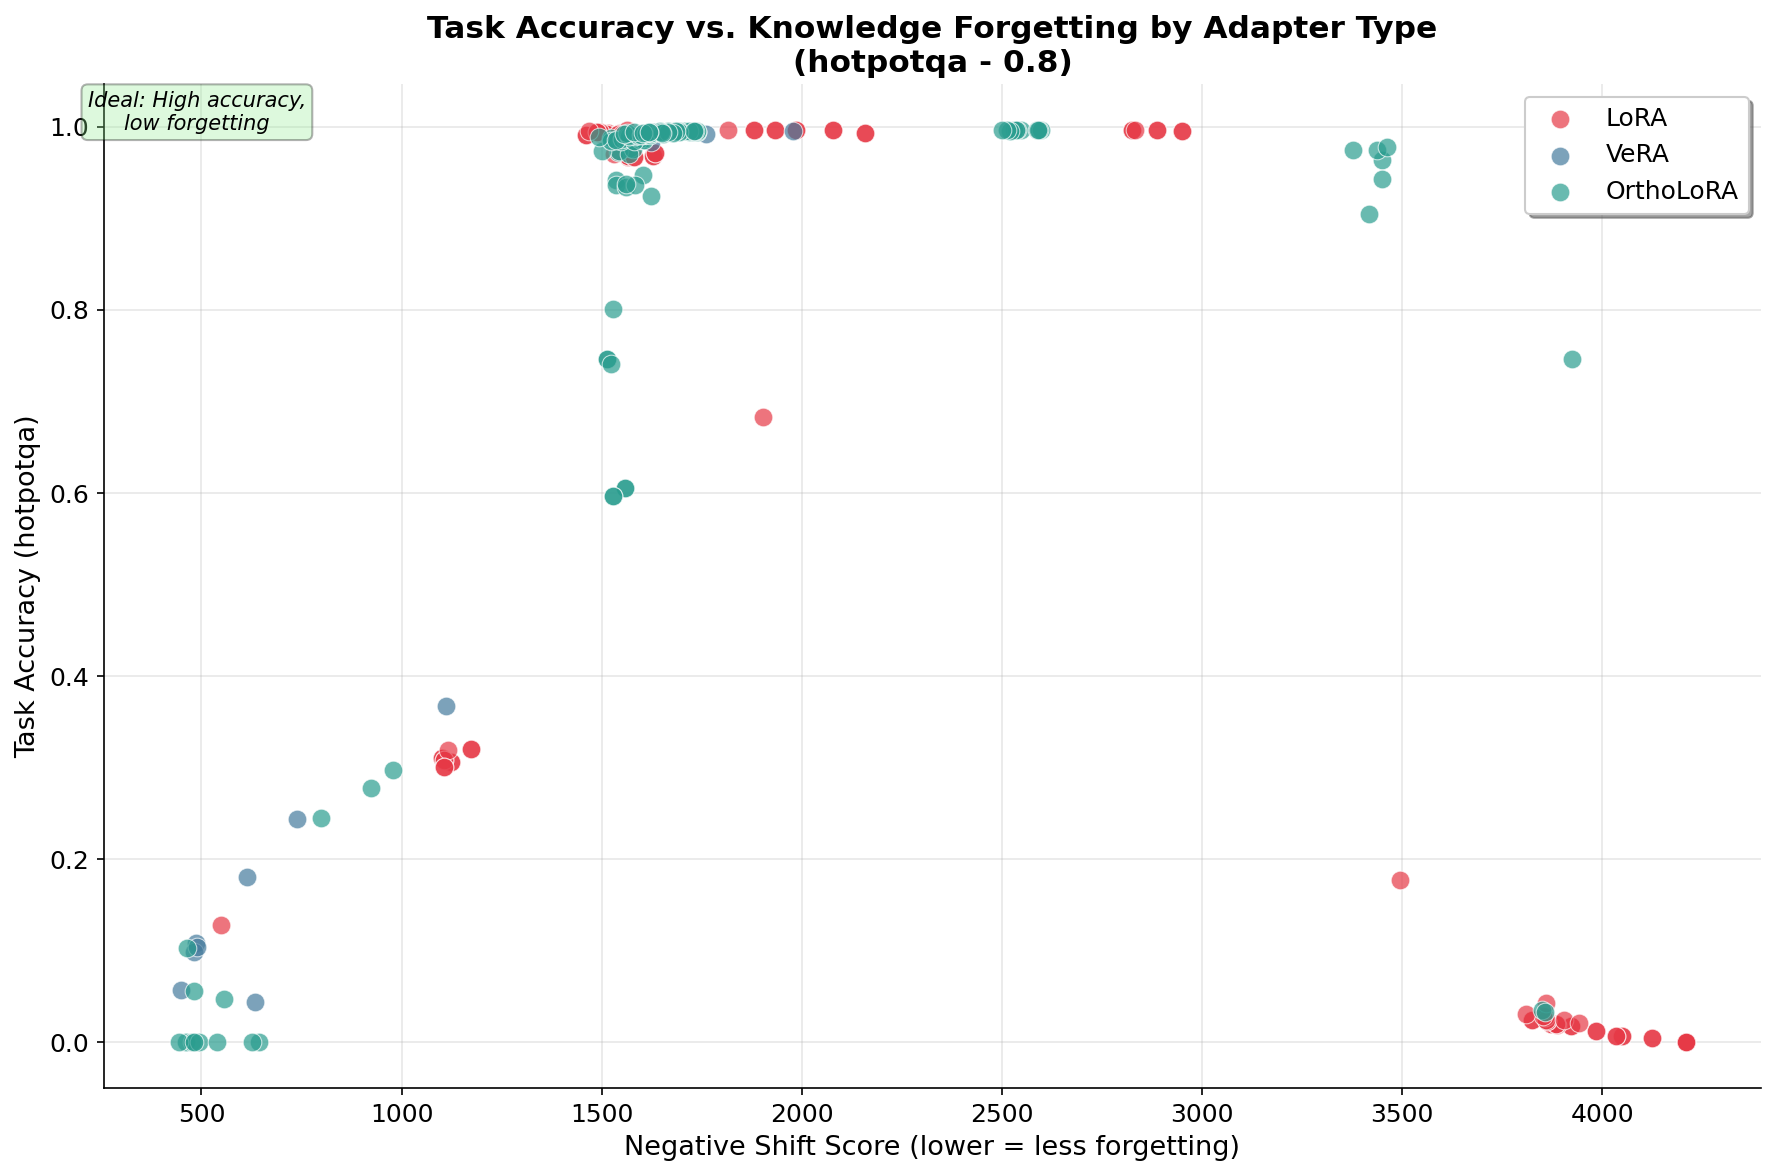

In [5]:
# FIGURE 1: Task Accuracy vs Negative Shift — Adapter Comparison
fig, ax = plt.subplots(figsize=(12, 8))

for adapter in ['lora', 'vera', 'uiortholora']:
    subset = df_merged[df_merged['adapter'] == adapter]
    subset = subset[subset['negative_shift_score'] > 0]  # Only valid shift scores
    ax.scatter(
        subset['negative_shift_score'],
        subset['accuracy'],
        c=ADAPTER_COLORS.get(adapter, 'gray'),
        label=ADAPTER_LABELS.get(adapter, adapter),
        alpha=0.7,
        s=80,
        edgecolors='white',
        linewidths=0.5,
        zorder=3
    )

ax.set_xlabel('Negative Shift Score (lower = less forgetting)', fontsize=13)
ax.set_ylabel(f'Task Accuracy ({DATASET})', fontsize=13)
ax.set_title(f'Task Accuracy vs. Knowledge Forgetting by Adapter Type\n({DATASET} - {THRESHOLD})', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)

# Annotation
ax.annotate('Ideal: High accuracy,\nlow forgetting',
            xy=(subset['negative_shift_score'].min() * 1.1, subset['accuracy'].max()), 
            fontsize=10, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.3),
            ha='center')

plt.tight_layout()
plt.show()

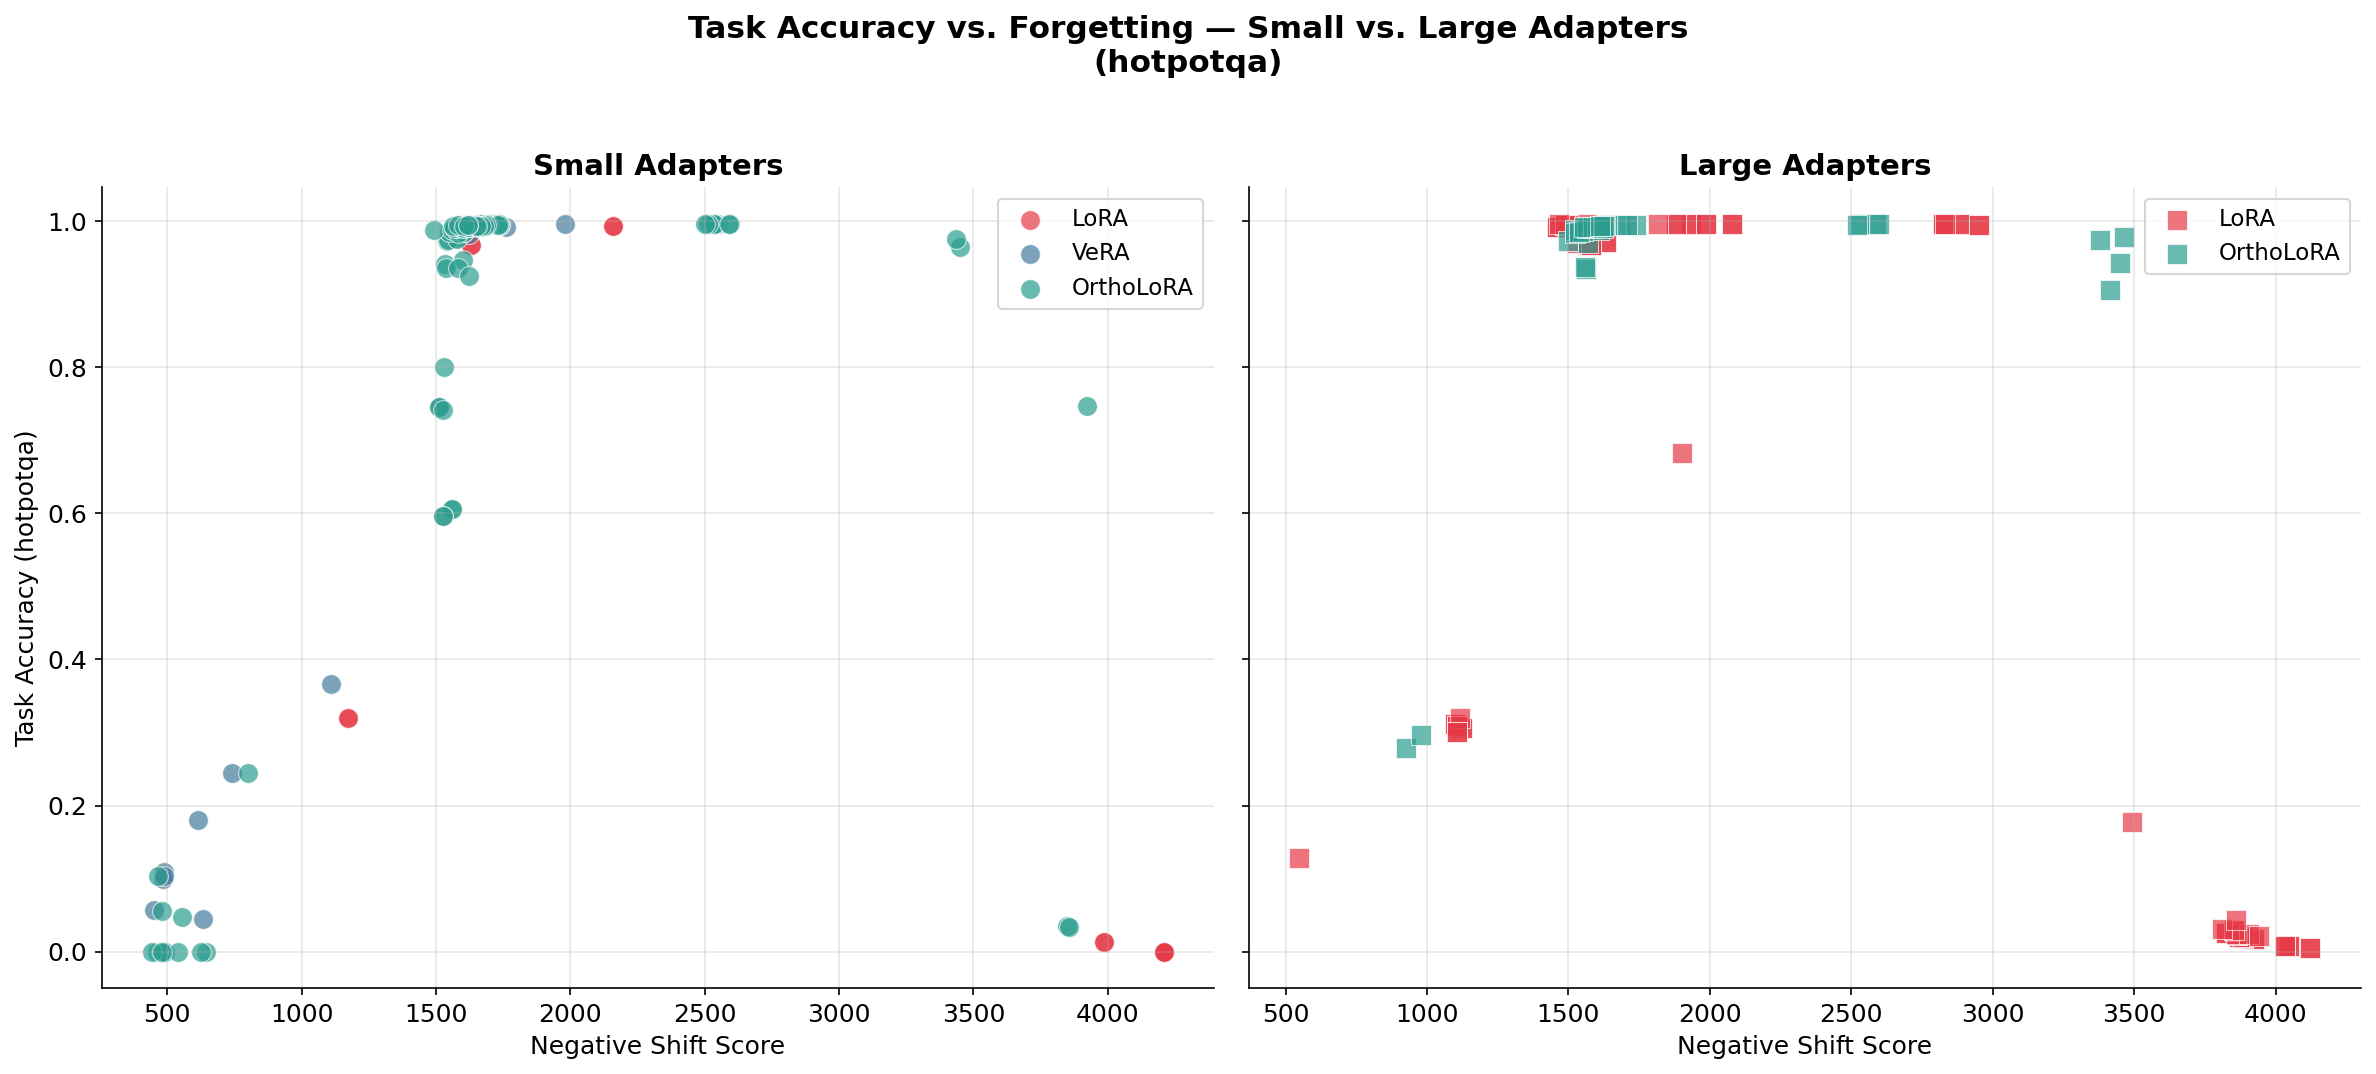

In [6]:
# FIGURE 2: Accuracy vs Negative Shift by Adapter SIZE
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for idx, size in enumerate(['small', 'large']):
    ax = axes[idx]
    subset = df_merged[(df_merged['size'] == size) & (df_merged['negative_shift_score'] > 0)]
    
    for adapter in ['lora', 'vera', 'uiortholora']:
        ad_sub = subset[subset['adapter'] == adapter]
        if len(ad_sub) > 0:
            ax.scatter(
                ad_sub['negative_shift_score'],
                ad_sub['accuracy'],
                c=ADAPTER_COLORS.get(adapter, 'gray'),
                label=ADAPTER_LABELS.get(adapter, adapter),
                alpha=0.7,
                s=90,
                edgecolors='white',
                linewidths=0.5,
                marker=SIZE_MARKERS.get(size, 'o')
            )
    
    ax.set_xlabel('Negative Shift Score', fontsize=12)
    ax.set_title(f'{size.capitalize()} Adapters', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, frameon=True)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(f'Task Accuracy ({DATASET})', fontsize=12)
fig.suptitle(f'Task Accuracy vs. Forgetting — Small vs. Large Adapters\n({DATASET})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

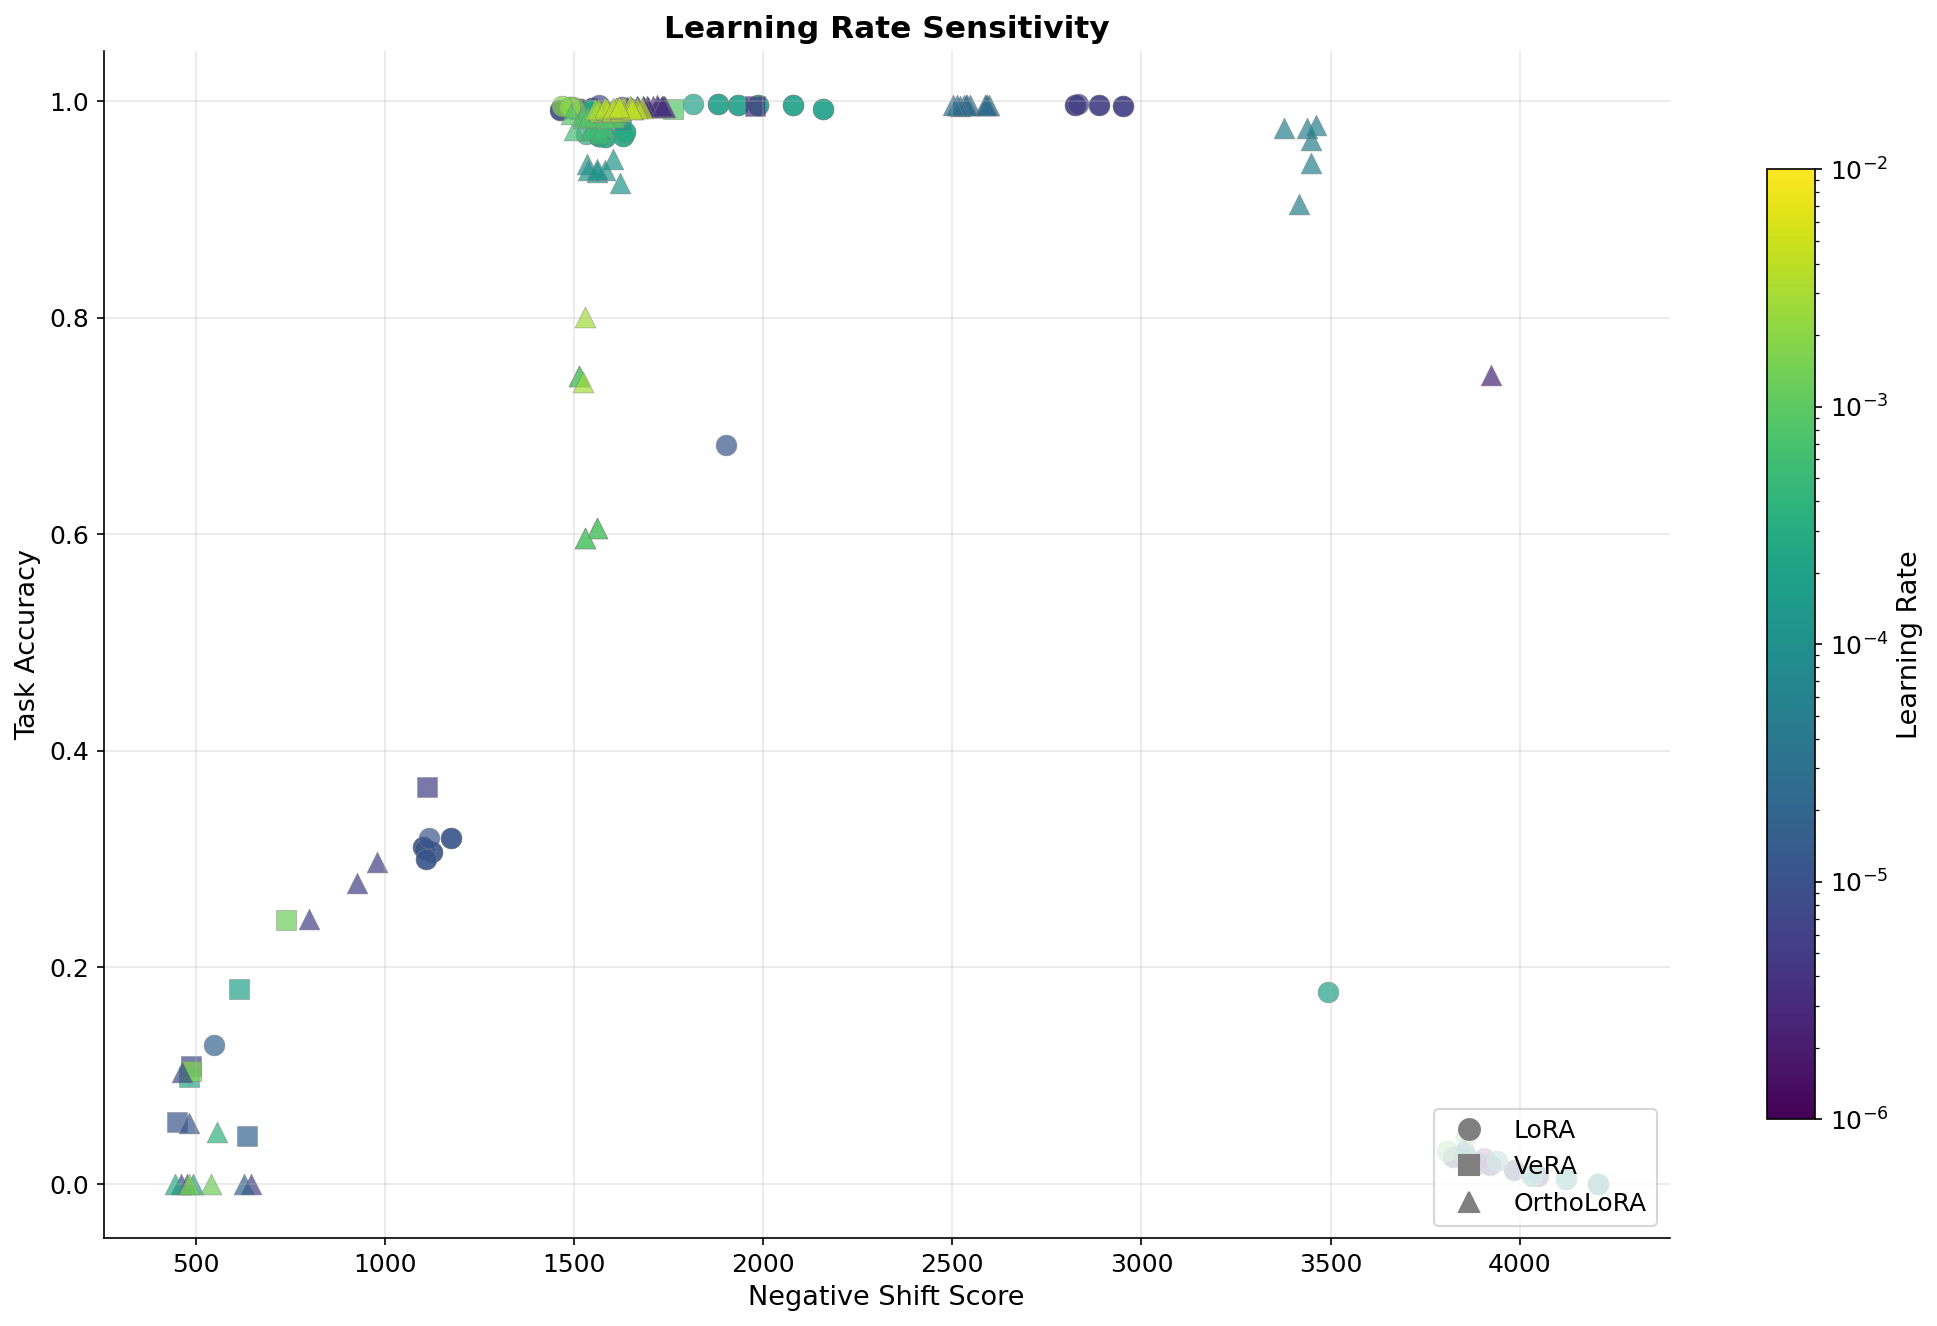

In [7]:
# FIGURE 3: Learning Rate Robustness
fig, ax = plt.subplots(figsize=(14, 9))

lr_vals = sorted(df_merged[df_merged['negative_shift_score'] > 0]['lr'].dropna().unique())
lr_cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(lr_vals)))
lr_color_map = {lr: lr_cmap[i] for i, lr in enumerate(lr_vals)}

marker_map = {'lora': 'o', 'vera': 's', 'uiortholora': '^'}

for adapter in ['lora', 'vera', 'uiortholora']:
    for lr_val in lr_vals:
        subset = df_merged[(df_merged['adapter'] == adapter) & 
                           (df_merged['lr'] == lr_val) & 
                           (df_merged['negative_shift_score'] > 0)]
        if len(subset) > 0:
            ax.scatter(
                subset['negative_shift_score'],
                subset['accuracy'],
                c=[lr_color_map[lr_val]],
                marker=marker_map.get(adapter, 'o'),
                s=100,
                alpha=0.7,
                edgecolors='gray',
                linewidths=0.3,
            )

# Legends
from matplotlib.lines import Line2D
adapter_handles = [Line2D([0],[0], marker=marker_map.get(a, 'o'), color='gray', 
                          markersize=10, linestyle='None', label=ADAPTER_LABELS.get(a, a)) 
                   for a in ['lora','vera','uiortholora']]

sm = plt.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e-2))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='Learning Rate', shrink=0.8)

ax.legend(handles=adapter_handles, fontsize=12, frameon=True, loc='lower right')
ax.set_xlabel('Negative Shift Score', fontsize=13)
ax.set_ylabel('Task Accuracy', fontsize=13)
ax.set_title('Learning Rate Sensitivity', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# FIGURE 5: MMLU vs BigBench for well-performing models
df_both = df_merged.dropna(subset=['bigbench_acc', 'mmlu_accuracy']).copy()

if len(df_both) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))

    for adapter in ['lora', 'vera', 'uiortholora']:
        subset = df_both[df_both['adapter'] == adapter]
        if len(subset) > 0:
            ax.scatter(
                subset['mmlu_accuracy'],
                subset['bigbench_acc'],
                c=ADAPTER_COLORS.get(adapter, 'gray'),
                label=ADAPTER_LABELS.get(adapter, adapter),
                alpha=0.7,
                s=90,
                edgecolors='white',
                linewidths=0.5,
            )

    ax.set_xlabel('MMLU Accuracy', fontsize=13)
    ax.set_ylabel('BigBench Mean Accuracy', fontsize=13)
    ax.set_title(f'General Knowledge Retention: MMLU vs BigBench\nafter {DATASET} Fine-tuning', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, frameon=True)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data with both BigBench and MMLU scores to plot Figure 5.")

Not enough data with both BigBench and MMLU scores to plot Figure 5.


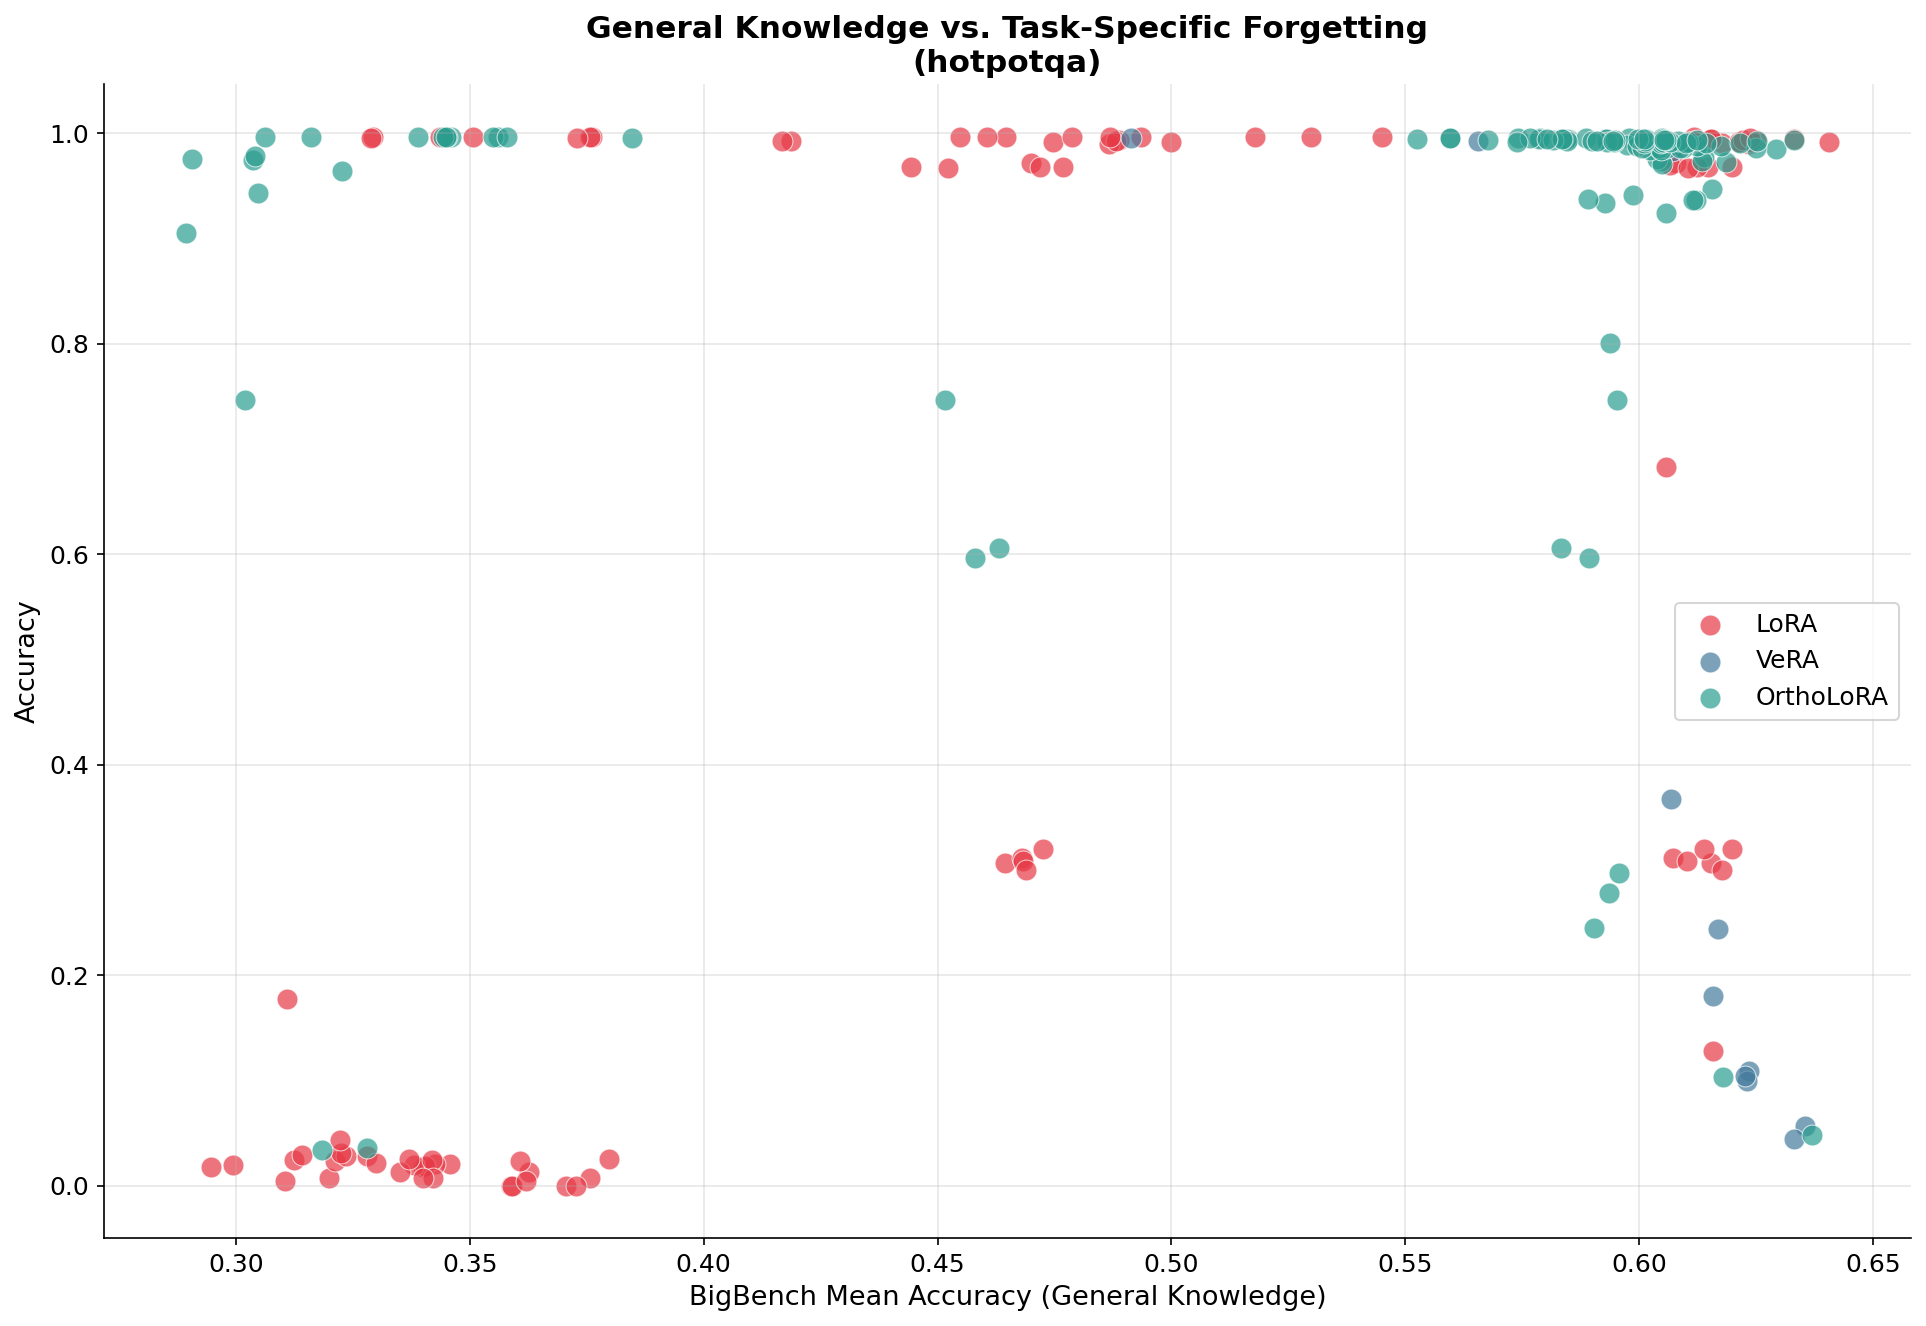

In [9]:
# FIGURE 8: BigBench vs Negative Shift
df_pareto = df_merged.dropna(subset=['bigbench_acc']).copy()
df_pareto = df_pareto[df_pareto['accuracy'] > 0]

if len(df_pareto) > 0:
    fig, ax = plt.subplots(figsize=(13, 9))

    for adapter in ['lora', 'vera', 'uiortholora']:
        subset = df_pareto[df_pareto['adapter'] == adapter]
        if len(subset) > 0:
            ax.scatter(
                subset['bigbench_acc'],
                subset['accuracy'],
                c=ADAPTER_COLORS.get(adapter, 'gray'),
                label=ADAPTER_LABELS.get(adapter, adapter),
                alpha=0.7,
                s=100,
                edgecolors='white',
                linewidths=0.5,
            )

    ax.set_ylabel('Accuracy', fontsize=13)
    ax.set_xlabel('BigBench Mean Accuracy (General Knowledge)', fontsize=13)
    ax.set_title(f'General Knowledge vs. Task-Specific Forgetting\n({DATASET})', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, frameon=True)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to plot BigBench vs Forgetting.")

In [10]:
# FIGURE 9: Summary table — best configs per adapter
df_summary = df_merged.dropna(subset=['bigbench_acc', 'mmlu_accuracy']).copy()

best_rows = []
for adapter in ['lora', 'vera', 'uiortholora']:
    sub = df_summary[df_summary['adapter'] == adapter]
    if len(sub) == 0:
        continue
    
    # Best by BigBench
    best_bb = sub.loc[sub['bigbench_acc'].idxmax()]
    best_rows.append({
        'Adapter': ADAPTER_LABELS.get(adapter, adapter),
        'LR': best_bb['lr'],
        'Task Acc': f"{best_bb['accuracy']:.3f}",
        'BigBench': f"{best_bb['bigbench_acc']:.3f}",
        'MMLU': f"{best_bb['mmlu_accuracy']:.3f}",
        'Neg Shift': f"{best_bb['negative_shift_score']:.0f}",
        'Metric': 'Best BigBench'
    })
    
    # Best by task acc with low forgetting (better than median)
    median_shift = sub['negative_shift_score'].median()
    low_forget = sub[sub['negative_shift_score'] < median_shift]
    if len(low_forget) > 0:
        best_task = low_forget.loc[low_forget['accuracy'].idxmax()]
        best_rows.append({
            'Adapter': ADAPTER_LABELS.get(adapter, adapter),
            'LR': best_task['lr'],
            'Task Acc': f"{best_task['accuracy']:.3f}",
            'BigBench': f"{best_task['bigbench_acc']:.3f}",
            'MMLU': f"{best_task['mmlu_accuracy']:.3f}",
            'Neg Shift': f"{best_task['negative_shift_score']:.0f}",
            'Metric': 'Best Task+Low Forget'
        })

df_best = pd.DataFrame(best_rows)
print("SUMMARY: Best Configurations per Adapter")
df_best

SUMMARY: Best Configurations per Adapter


""
